# 강판 표면 결함 다중분류
### Random Forest

철판 조건, 경계·형상 정보, 결함 크기 정보를 이용해 7개 결함 유형을 분류한다.

- EDA: 공통 피처 10개와 크기 피처 3개의 분포 확인
- 최종 학습: Random Forest, Stratified 5-Fold, RandomizedSearchCV
- 평가: Accuracy, Macro F1, 분류 보고서, 혼동행렬, 피처 중요도

**[1] 라이브러리 불러오기**

In [ ]:
# --------------------------------------------------
# 라이브러리
# --------------------------------------------------
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_validate, RandomizedSearchCV
)
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

N_JOBS = 1

**[2] 데이터 불러오기**

In [ ]:
# --------------------------------------------------
# 데이터 불러오기
# --------------------------------------------------
csv_path = './steel_plate_faults_multiclass.csv'
dataDF = pd.read_csv(csv_path)

print(f'[전체 데이터 크기] {dataDF.shape}')
display(dataDF.head())

[전체 데이터 크기] (1941, 28)


,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Fault_Type
0,42,50,270900,270944,267,17,44,24220,76,108,...,0.4706,1.0000,1.0,2.4265,0.9031,1.6435,0.8182,-0.2913,0.5822,Pastry
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,0.6000,0.9667,1.0,2.0334,0.7782,1.4624,0.7931,-0.1756,0.2984,Pastry
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,0.7500,0.9474,1.0,1.8513,0.7782,1.2553,0.6667,-0.1228,0.2150,Pastry
3,853,860,369370,369415,176,13,45,18996,99,126,...,0.5385,1.0000,1.0,2.2455,0.8451,1.6532,0.8444,-0.1568,0.5212,Pastry
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,0.2833,0.9885,1.0,3.3818,1.2305,2.4099,0.9338,-0.1992,1.0000,Pastry


Random Forest는 문자열 형태의 타깃도 바로 학습할 수 있으므로 별도의 라벨 인코딩을 적용하지 않았다.

**[3] 데이터 품질 확인**

In [ ]:
# --------------------------------------------------
# 데이터 구조 및 품질 확인
# --------------------------------------------------
dataDF.info()

missing_count = dataDF.isnull().sum().sum()
duplicate_count = dataDF.duplicated().sum()

print(f'\n[전체 결측치 개수] {missing_count}개')
print(f'[완전 중복 행 개수] {duplicate_count}개')

print('\n[결함 유형별 데이터 개수]')
target_count = dataDF['Fault_Type'].value_counts()
display(target_count.to_frame('count'))

print('\n[결함 유형별 비율(%)]')
target_ratio = dataDF['Fault_Type'].value_counts(normalize=True) * 100
display(target_ratio.round(2).to_frame('ratio_%'))

[컬럼 자료형]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1941 entries, 0 to 1940
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   X_Minimum              1941 non-null   int64  
 1   X_Maximum              1941 non-null   int64  
 2   Y_Minimum              1941 non-null   int64  
 3   Y_Maximum              1941 non-null   int64  
 4   Pixels_Areas           1941 non-null   int64  
 5   X_Perimeter            1941 non-null   int64  
 6   Y_Perimeter            1941 non-null   int64  
 7   Sum_of_Luminosity      1941 non-null   int64  
 8   Minimum_of_Luminosity  1941 non-null   int64  
 9   Maximum_of_Luminosity  1941 non-null   int64  
 10  Length_of_Conveyer     1941 non-null   int64  
 11  TypeOfSteel_A300       1941 non-null   int64  
 12  TypeOfSteel_A400       1941 non-null   int64  
 13  Steel_Plate_Thickness  1941 non-null   int64  
 14  Edges_Index            1941 non-null   float64


,count
Fault_Type,
Other_Faults,673
Bumps,402
K_Scatch,391
Z_Scratch,190
Pastry,158
Stains,72
Dirtiness,55



[결함 유형별 비율(%)]


,ratio_%
Fault_Type,
Other_Faults,34.67
Bumps,20.71
K_Scatch,20.14
Z_Scratch,9.79
Pastry,8.14
Stains,3.71
Dirtiness,2.83


**[4] 사용할 컬럼 선택**

In [ ]:
# --------------------------------------------------
# EDA에 사용할 피처
# --------------------------------------------------
common_columns = [
    'TypeOfSteel_A300', 'TypeOfSteel_A400',
    'Steel_Plate_Thickness', 'Edges_Index',
    'Empty_Index', 'Square_Index',
    'Outside_X_Index', 'Edges_X_Index',
    'Edges_Y_Index', 'Outside_Global_Index'
]

size_columns = ['Pixels_Areas', 'X_Perimeter', 'Y_Perimeter']
target_column = 'Fault_Type'
class_names = sorted(dataDF[target_column].unique())

print(f'공통 피처: {len(common_columns)}개')
print(f'크기 피처: {len(size_columns)}개')

공통 피처에 `Square_Index`, `Edges_X_Index`, `Edges_Y_Index`, `Outside_Global_Index`와 같은 형상·방향 정보가 포함되어 있다. 따라서 둘레 피처를 추가로 파생하기보다 원본 `X_Perimeter`, `Y_Perimeter`를 사용했다.

**[4-1] 피처와 결함 유형의 관계 시각화**

**(1) 연속형 피처 10개 Box Plot**

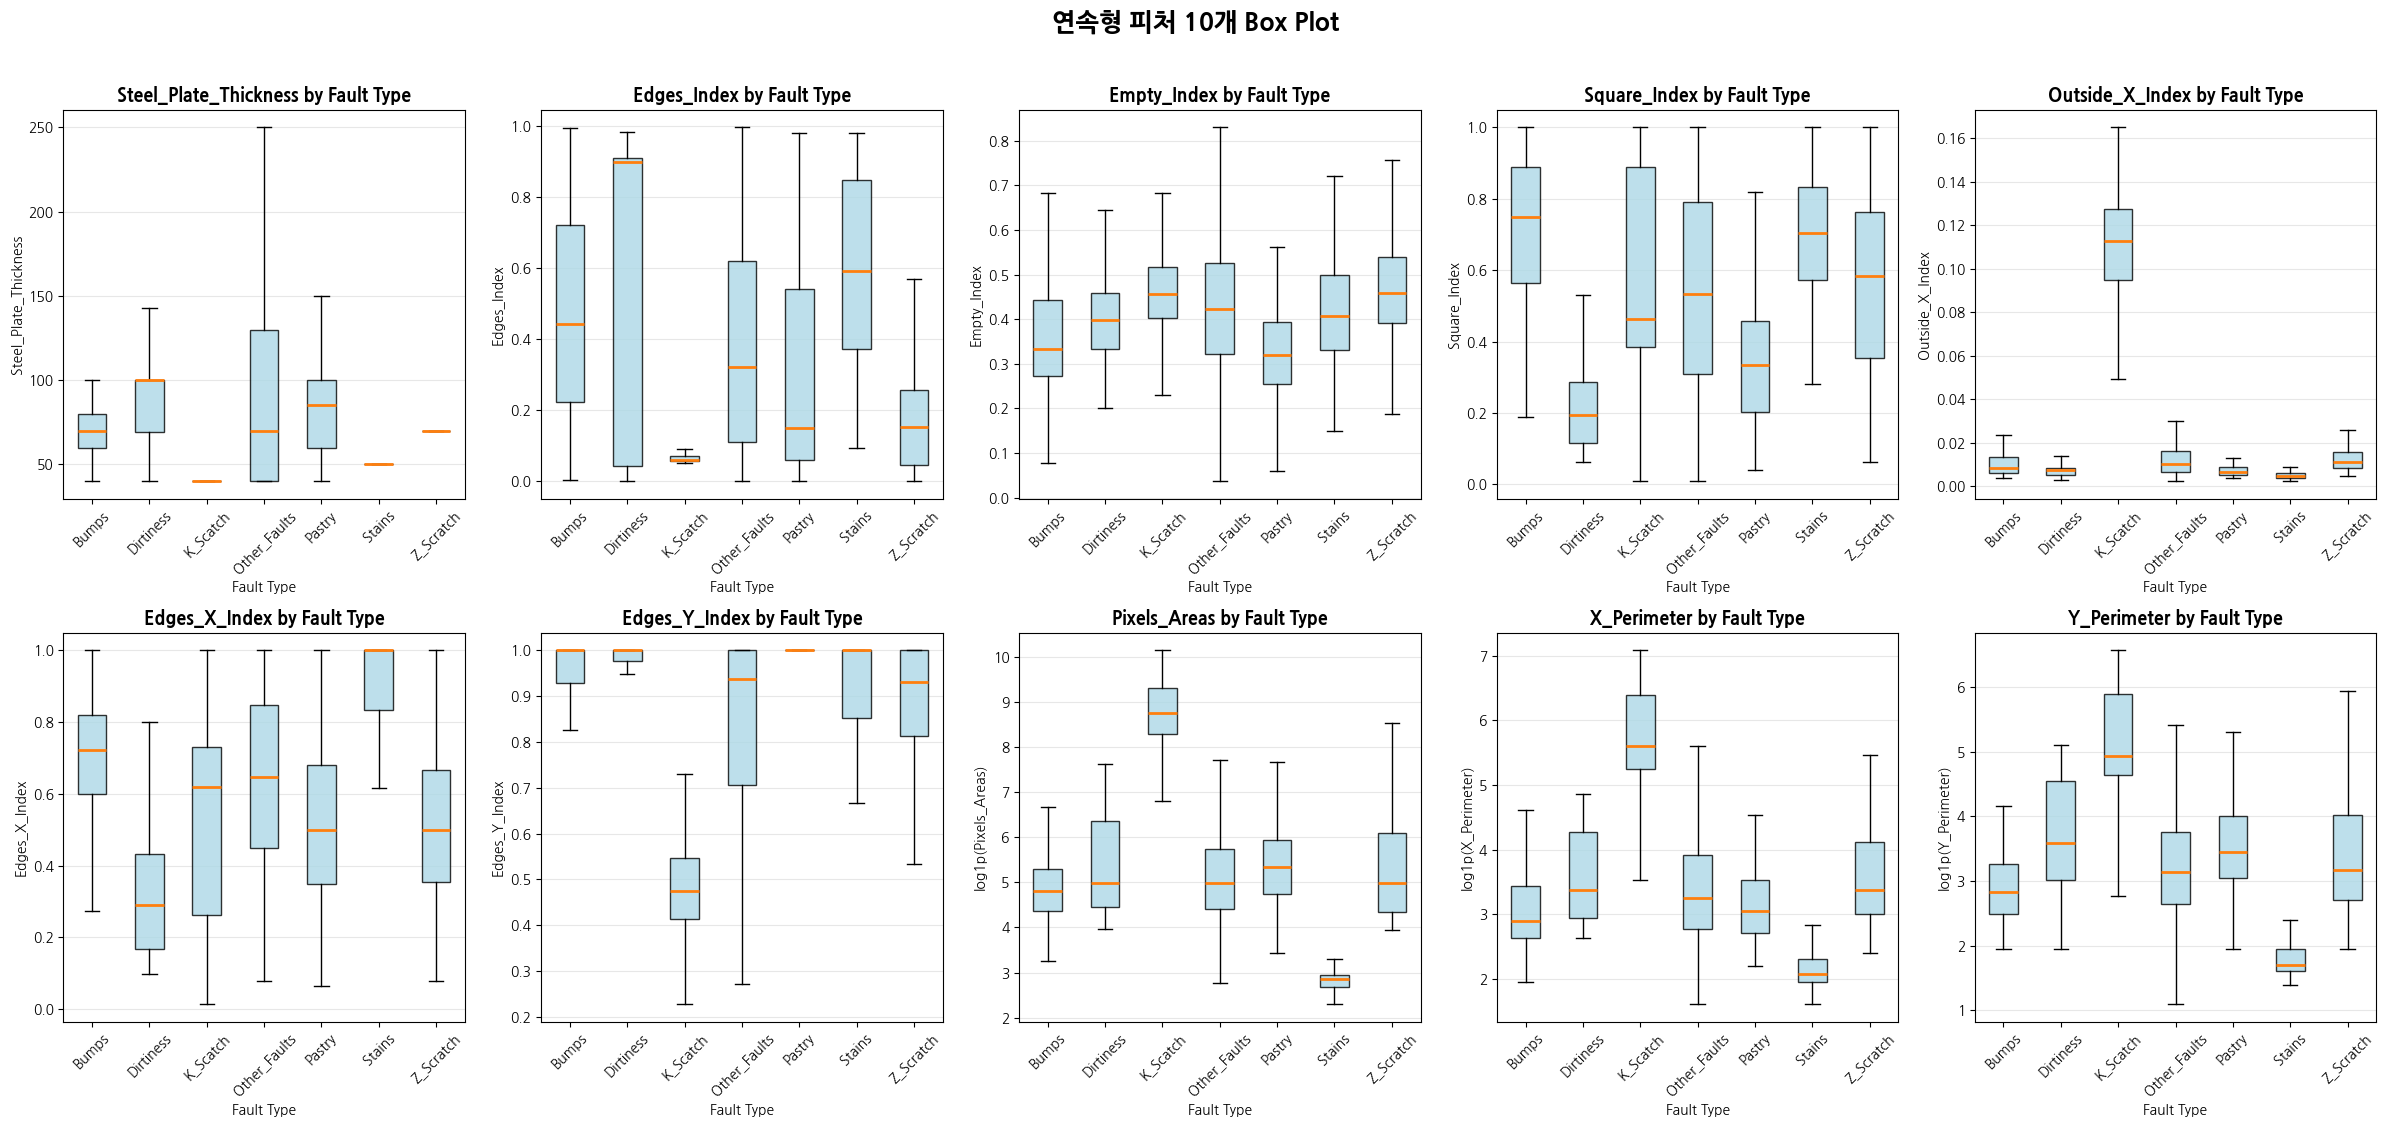

In [ ]:
# --------------------------------------------------
# 결함 유형별 연속형 피처 분포
# --------------------------------------------------
continuous_columns = [
    'Steel_Plate_Thickness', 'Edges_Index', 'Empty_Index',
    'Square_Index', 'Outside_X_Index', 'Edges_X_Index',
    'Edges_Y_Index', 'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter'
]

fig, axes = plt.subplots(2, 5, figsize=(24, 11))
axes = axes.flatten()

for ax, column in zip(axes, continuous_columns):
    plot_values = []

    for class_name in class_names:
        values = dataDF.loc[dataDF[target_column] == class_name, column]

        # 값의 범위가 큰 크기 피처만 로그 변환
        if column in size_columns:
            values = np.log1p(values)

        plot_values.append(values)

    boxplot = ax.boxplot(
        plot_values,
        tick_labels=class_names,
        patch_artist=True,
        showfliers=False,
        medianprops={'linewidth': 2}
    )

    for box in boxplot['boxes']:
        box.set_facecolor('lightblue')
        box.set_alpha(0.8)

    ax.set_title(f'{column} by Fault Type', fontsize=13, fontweight='bold')
    ax.set_xlabel('Fault Type')
    ax.set_ylabel(f'log1p({column})' if column in size_columns else column)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('연속형 피처 10개 Box Plot', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**(2) 철판 종류와 결함 7종 관계**

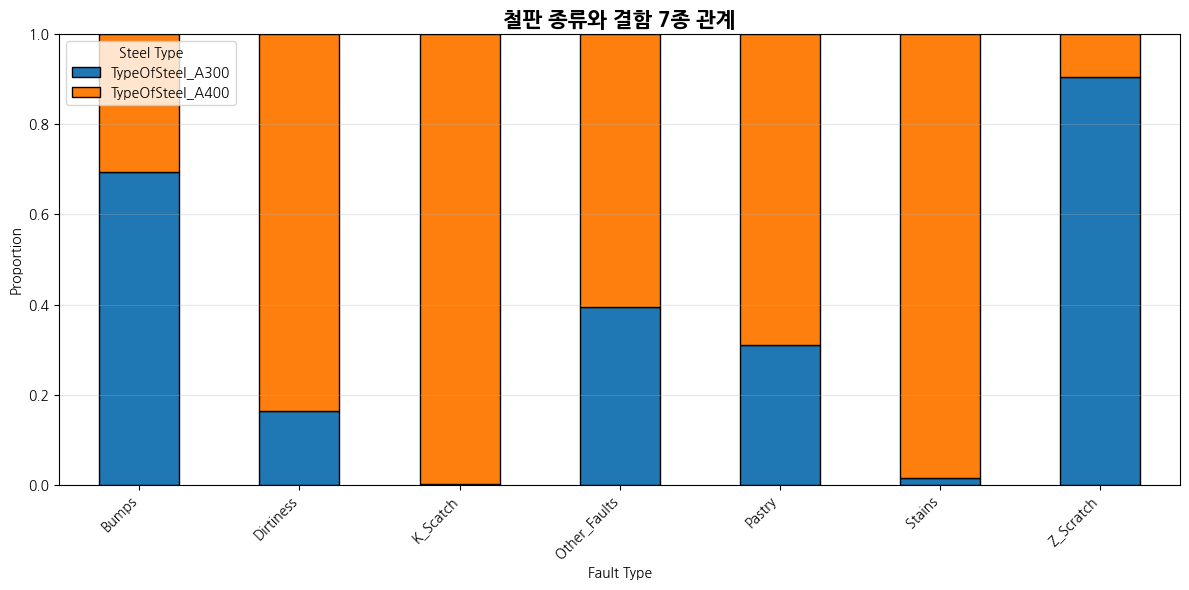

In [ ]:
# --------------------------------------------------
# 결함 유형별 철판 종류 비율
# --------------------------------------------------
steel_type_ratioDF = (
    dataDF.groupby(target_column)[['TypeOfSteel_A300', 'TypeOfSteel_A400']]
    .mean()
    .reindex(class_names)
)

ax = steel_type_ratioDF.plot(
    kind='bar', stacked=True, figsize=(12, 6), edgecolor='black'
)

plt.title('철판 종류와 결함 7종 관계', fontsize=15, fontweight='bold')
plt.xlabel('Fault Type')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.legend(title='Steel Type')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**[5] 입력 피처 기초통계**

In [ ]:
# --------------------------------------------------
# 최종 학습 피처
# --------------------------------------------------
feature_columns = [
    'Length_of_Conveyer', 'Steel_Plate_Thickness',
    'Empty_Index', 'Square_Index', 'Edges_Index',
    'Outside_Global_Index', 'LogOfAreas', 'Log_X_Index',
    'Edges_X_Index', 'Edges_Y_Index',
    'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter'
]

X = dataDF[feature_columns].copy()
y = dataDF[target_column].copy()

display(X.describe().T)

,count,mean,std,min,25%,50%,75%,max
Length_of_Conveyer,1941.0,1459.160227,144.577823,1227.0000,1358.0000,1364.0000,1650.0000,1794.0000
Steel_Plate_Thickness,1941.0,78.737764,55.086032,40.0000,40.0000,70.0000,80.0000,300.0000
Empty_Index,1941.0,0.414203,0.137261,0.0000,0.3158,0.4121,0.5016,0.9439
Square_Index,1941.0,0.570767,0.271058,0.0083,0.3613,0.5556,0.8182,1.0000
Edges_Index,1941.0,0.331715,0.299712,0.0000,0.0604,0.2273,0.5738,0.9952
Outside_Global_Index,1941.0,0.575734,0.482352,0.0000,0.0000,1.0000,1.0000,1.0000
LogOfAreas,1941.0,2.492388,0.788930,0.3010,1.9243,2.2406,2.9149,5.1837
Log_X_Index,1941.0,1.335686,0.481612,0.3010,1.0000,1.1761,1.5185,3.0741
Edges_X_Index,1941.0,0.610529,0.243277,0.0144,0.4118,0.6364,0.8000,1.0000
Edges_Y_Index,1941.0,0.813472,0.234274,0.0484,0.5968,0.9474,1.0000,1.0000


**[6] Train/Test 분리**

In [ ]:
# --------------------------------------------------
# 학습 데이터와 테스트 데이터 분리
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print('[전체 데이터]')
print(f'X: {X.shape}, y: {y.shape}')
print('\n[학습 데이터]')
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print('\n[테스트 데이터]')
print(f'X_test: {X_test.shape}, y_test: {y_test.shape}')

[전체 데이터]
X: (1941, 13), y: (1941,)

[학습 데이터]
X_train: (1552, 13), y_train: (1552,)

[테스트 데이터]
X_test: (389, 13), y_test: (389,)


In [ ]:
# --------------------------------------------------
# Train/Test 클래스 비율 확인
# --------------------------------------------------
train_class_ratio = y_train.value_counts(normalize=True).sort_index() * 100
test_class_ratio = y_test.value_counts(normalize=True).sort_index() * 100

class_ratioDF = pd.DataFrame({
    'Train 비율(%)': train_class_ratio.round(2),
    'Test 비율(%)': test_class_ratio.round(2)
})

display(class_ratioDF)

,Train 비율(%),Test 비율(%)
Fault_Type,,
Bumps,20.68,20.82
Dirtiness,2.84,2.83
K_Scatch,20.17,20.05
Other_Faults,34.66,34.70
Pastry,8.12,8.23
Stains,3.74,3.60
Z_Scratch,9.79,9.77


**[7] Random Forest 모델 생성**

여러 개의 결정트리를 학습한 뒤 결과를 종합해 7개 결함 유형을 분류한다.

In [ ]:
# --------------------------------------------------
# Random Forest Pipeline
# --------------------------------------------------
model_pipeline = Pipeline([
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_features='sqrt',
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=N_JOBS
    ))
])

print(model_pipeline)

Pipeline(steps=[('model',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        n_estimators=200, n_jobs=1,
                                        random_state=42))])


**[8] Stratified 5-Fold 교차검증**

In [ ]:
# --------------------------------------------------
# 교차검증 설정
# --------------------------------------------------
skFold = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)

score = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted'
}

cross_validation_result = cross_validate(
    model_pipeline,
    X_train,
    y_train,
    cv=skFold,
    scoring=score,
    return_train_score=True,
    n_jobs=N_JOBS
)

cross_validationDF = pd.DataFrame({
    'Fold': range(1, 6),
    'Train Accuracy': cross_validation_result['train_accuracy'],
    'Valid Accuracy': cross_validation_result['test_accuracy'],
    'Valid Precision Macro': cross_validation_result['test_precision_macro'],
    'Valid Recall Macro': cross_validation_result['test_recall_macro'],
    'Valid F1 Macro': cross_validation_result['test_f1_macro'],
    'Valid F1 Weighted': cross_validation_result['test_f1_weighted']
})

display(cross_validationDF.round(4))

,Fold,Train Accuracy,Valid Accuracy,Valid Precision Macro,Valid Recall Macro,Valid F1 Macro,Valid F1 Weighted
0,1,1.0,0.7042,0.8153,0.6830,0.7349,0.7072
1,2,1.0,0.7203,0.7985,0.7052,0.7348,0.7191
2,3,1.0,0.7903,0.8248,0.7858,0.8013,0.7901
3,4,1.0,0.7194,0.7491,0.6784,0.7036,0.7142
4,5,1.0,0.7645,0.8057,0.7813,0.7895,0.7647


| 평가지표 | 확인 목적 |
|---|---|
| Accuracy | 전체 데이터 중 정확히 분류한 비율 |
| Precision Macro | 각 결함 예측의 정확성 |
| Recall Macro | 실제 결함을 찾아낸 비율 |
| Macro F1 | 7개 결함을 동일한 비중으로 평가 |
| Weighted F1 | 클래스별 표본 수를 반영한 F1 |

**[9] RandomizedSearchCV**

In [ ]:
# --------------------------------------------------
# 하이퍼파라미터 후보
# --------------------------------------------------
param_dict = {
    'model__n_estimators': [200, 300, 500],
    'model__max_depth': [10, 15, 20, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 0.5],
    'model__bootstrap': [True],
    'model__class_weight': [None, 'balanced']
}

searchModel = RandomizedSearchCV(
    model_pipeline,
    param_distributions=param_dict,
    n_iter=10,
    scoring={'accuracy': 'accuracy', 'f1_macro': 'f1_macro'},
    refit='f1_macro',
    cv=skFold,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

searchModel.fit(X_train, y_train)
best_pipeline = searchModel.best_estimator_

print('[최적 하이퍼파라미터]')
print(searchModel.best_params_)
print(f'\n[최고 교차검증 Macro F1] {searchModel.best_score_:.4f}')

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[최적 하이퍼파라미터]
{'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 15, 'model__class_weight': 'balanced', 'model__bootstrap': True}

[최고 교차검증 Macro F1] 0.7636


**[10] 최종 모델 학습 및 테스트 평가**

In [ ]:
# --------------------------------------------------
# 튜닝 모델 테스트 평가
# --------------------------------------------------
y_pred = best_pipeline.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
test_f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)

print(f'테스트 정확도: {test_accuracy:.4f}')
print(f'테스트 Macro F1: {test_f1_macro:.4f}')
print('\n[분류 보고서]')
print(classification_report(y_test, y_pred, zero_division=0))

테스트 정확도: 0.7455
테스트 Macro F1: 0.7554

[분류 보고서]
              precision    recall  f1-score   support

       Bumps       0.72      0.68      0.70        81
   Dirtiness       0.67      0.73      0.70        11
    K_Scatch       0.94      0.87      0.91        78
Other_Faults       0.68      0.72      0.70       135
      Pastry       0.55      0.56      0.55        32
      Stains       1.00      0.86      0.92        14
   Z_Scratch       0.78      0.84      0.81        38

    accuracy                           0.75       389
   macro avg       0.76      0.75      0.76       389
weighted avg       0.75      0.75      0.75       389



- `max_depth=15`: 트리의 복잡도 제한
- `min_samples_split=5`: 지나치게 작은 노드 분할 억제
- `class_weight='balanced'`: 소수 클래스 반영
- `n_estimators=500`: 여러 트리의 결과를 평균해 예측 안정화

In [ ]:
# --------------------------------------------------
# 기본 모델과 튜닝 모델 비교
# --------------------------------------------------
model_pipeline.fit(X_train, y_train)
base_pred = model_pipeline.predict(X_test)
tuned_pred = best_pipeline.predict(X_test)

base_accuracy = accuracy_score(y_test, base_pred)
base_f1_macro = f1_score(y_test, base_pred, average='macro', zero_division=0)

tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_f1_macro = f1_score(y_test, tuned_pred, average='macro', zero_division=0)

print('[기본 모델]')
print(f'Accuracy : {base_accuracy:.4f}')
print(f'Macro F1 : {base_f1_macro:.4f}')

print('\n[튜닝 모델]')
print(f'Accuracy : {tuned_accuracy:.4f}')
print(f'Macro F1 : {tuned_f1_macro:.4f}')

[기본 모델]
Accuracy : 0.7429
Macro F1 : 0.7524

[튜닝 모델]
Accuracy : 0.7455
Macro F1 : 0.7554


**[11] 최종 성능 정리**

In [ ]:
# --------------------------------------------------
# 최종 성능 계산
# --------------------------------------------------
y_train_pred = best_pipeline.predict(X_train)
y_pred = best_pipeline.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
test_recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
test_f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
test_f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)

final_scoreDF = pd.DataFrame({
    '평가지표': [
        'Train Accuracy', 'Test Accuracy',
        'Test Precision Macro', 'Test Recall Macro',
        'Test F1 Macro', 'Test F1 Weighted'
    ],
    '점수': [
        train_accuracy, test_accuracy,
        test_precision, test_recall,
        test_f1_macro, test_f1_weighted
    ]
})

display(final_scoreDF.round(4))

,평가지표,점수
0,Train Accuracy,0.9839
1,Test Accuracy,0.7455
2,Test Precision Macro,0.7627
3,Test Recall Macro,0.7512
4,Test F1 Macro,0.7554
5,Test F1 Weighted,0.7475


In [ ]:
# --------------------------------------------------
# 결함 유형별 성능
# --------------------------------------------------
report_dict = classification_report(
    y_test, y_pred,
    output_dict=True,
    zero_division=0
)

classification_reportDF = pd.DataFrame(report_dict).T
display(classification_reportDF.round(4))

,precision,recall,f1-score,support
Bumps,0.7237,0.6790,0.7006,81.0000
Dirtiness,0.6667,0.7273,0.6957,11.0000
K_Scatch,0.9444,0.8718,0.9067,78.0000
Other_Faults,0.6783,0.7185,0.6978,135.0000
Pastry,0.5455,0.5625,0.5538,32.0000
Stains,1.0000,0.8571,0.9231,14.0000
Z_Scratch,0.7805,0.8421,0.8101,38.0000
accuracy,0.7455,0.7455,0.7455,0.7455
macro avg,0.7627,0.7512,0.7554,389.0000
weighted avg,0.7514,0.7455,0.7475,389.0000


**[12] 혼동행렬**

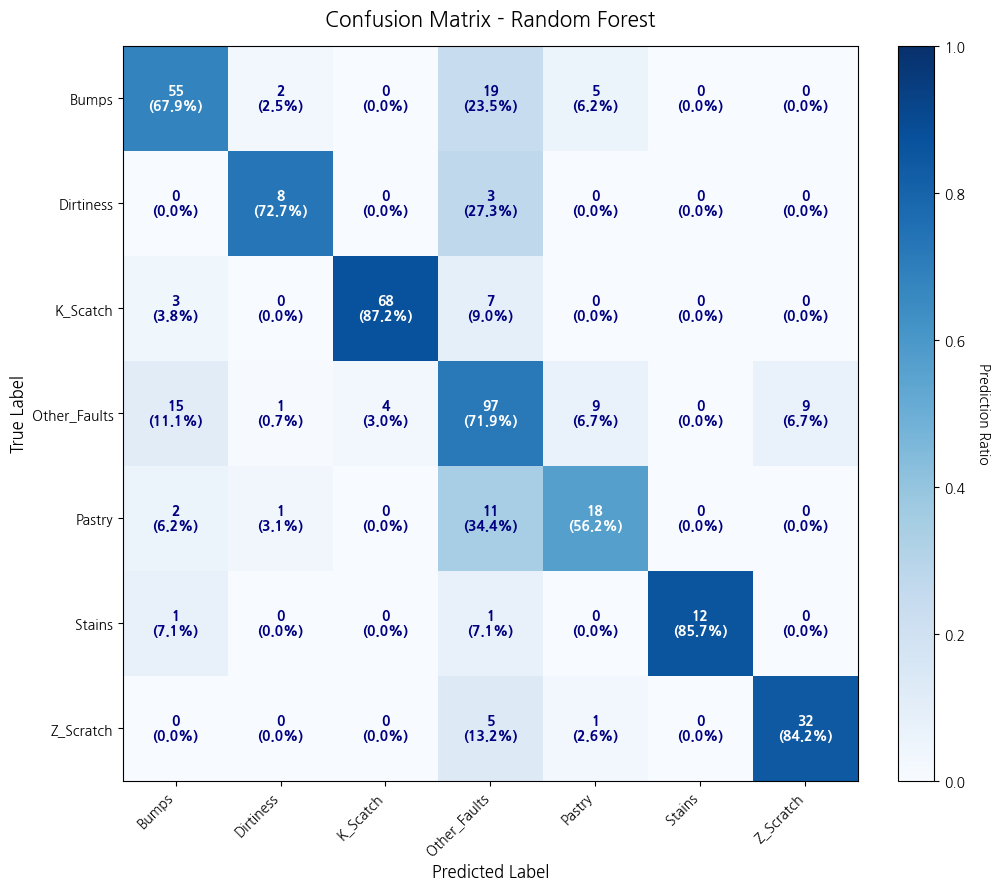

In [ ]:
# --------------------------------------------------
# 혼동행렬
# --------------------------------------------------
class_names = sorted(y.unique())
confusion = confusion_matrix(y_test, y_pred, labels=class_names)
confusion_ratio = confusion / confusion.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(11, 9))
image = ax.imshow(confusion_ratio, cmap='Blues', vmin=0, vmax=1)

ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)

for row in range(len(class_names)):
    for column in range(len(class_names)):
        count = confusion[row, column]
        ratio = confusion_ratio[row, column]
        text_color = 'white' if ratio >= 0.5 else 'navy'

        ax.text(
            column, row,
            f'{count}\n({ratio:.1%})',
            ha='center', va='center',
            color=text_color,
            fontsize=10,
            fontweight='bold'
        )

ax.set_title('Confusion Matrix - Random Forest', fontsize=15, pad=15)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)

colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
colorbar.set_label('Prediction Ratio', rotation=270, labelpad=18)

plt.tight_layout()
plt.show()

**[13] 피처 중요도**

입력 피처 개수: 13
피처 중요도 개수: 13


,Feature,Importance
0,LogOfAreas,0.1125
1,Pixels_Areas,0.1102
2,Length_of_Conveyer,0.1072
3,Steel_Plate_Thickness,0.1011
4,Log_X_Index,0.0927
5,Square_Index,0.0840
6,Edges_Index,0.0829
7,X_Perimeter,0.0653
8,Y_Perimeter,0.0627
9,Edges_X_Index,0.0592


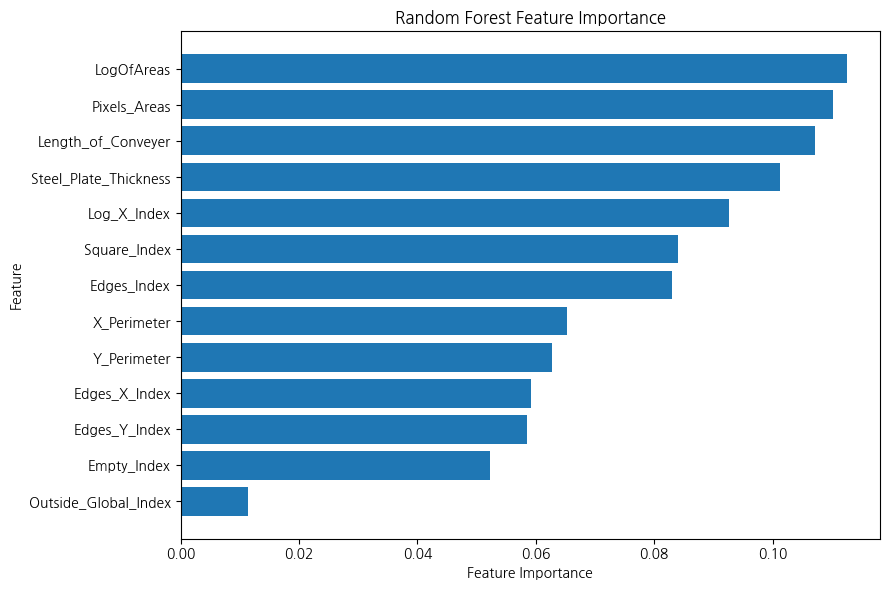

In [ ]:
# --------------------------------------------------
# Random Forest 피처 중요도
# --------------------------------------------------
fitted_model = best_pipeline.named_steps['model']

print(f'입력 피처 개수: {len(feature_columns)}')
print(f'피처 중요도 개수: {len(fitted_model.feature_importances_)}')

feature_importanceDF = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': fitted_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

display(feature_importanceDF.round(4))

plt.figure(figsize=(9, 6))
plt.barh(feature_importanceDF['Feature'], feature_importanceDF['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

**[14] 결과 해석**

In [ ]:
# --------------------------------------------------
# 최적 모델의 교차검증 결과와 과적합 정도
# --------------------------------------------------
best_index = searchModel.best_index_

cv_accuracy_mean = searchModel.cv_results_['mean_test_accuracy'][best_index]
cv_accuracy_std = searchModel.cv_results_['std_test_accuracy'][best_index]
cv_f1_mean = searchModel.cv_results_['mean_test_f1_macro'][best_index]
cv_f1_std = searchModel.cv_results_['std_test_f1_macro'][best_index]
overfit_gap = train_accuracy - test_accuracy

print('[튜닝 모델 결과 해석]')
print(f'1. 5-Fold 검증 정확도 평균: {cv_accuracy_mean:.4f} (±{cv_accuracy_std:.4f})')
print(f'2. 5-Fold 검증 Macro F1 평균: {cv_f1_mean:.4f} (±{cv_f1_std:.4f})')
print(f'3. 최종 테스트 정확도: {test_accuracy:.4f}')
print(f'4. 최종 테스트 Macro F1: {test_f1_macro:.4f}')
print(f'5. Train-Test 정확도 차이: {overfit_gap:.4f}')

[튜닝 모델 결과 해석]
1. 5-Fold 검증 정확도 평균: 0.7468 (±0.0276)
2. 5-Fold 검증 Macro F1 평균: 0.7636 (±0.0354)
3. 최종 테스트 정확도: 0.7455
4. 최종 테스트 Macro F1: 0.7554
5. Train-Test 정확도 차이: 0.2384
